In [1]:
import sys
root_path = '../' # This defaults to './', which should be the repository path
sys.path.append(root_path)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

import networkx as nx

from utils.config import path_to_cascade_results, path_to_pypsa_network_sclopf
from utils.plot_mitigation_strategies import plot_map_inertia_placement_final
from utils import data_handling

In [2]:
# Load network graph and node positions
# (it is equal for all CO2 levels)
snet_index = 0
network = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
                        "sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc", True)
nx_graph = data_handling.build_networkx_graph(network, snet_index= snet_index)
pos = nx.get_node_attributes(nx_graph, 'pos')
I_m, B_d, num_parallels, line_limits = data_handling.get_matrices_from_nx_graph(nx_graph)

# Determine number of simulations,
# i.e., total number of initial failures over the simulated period of one year
# bridge_idxs = data_handling.nx_edges_to_matrix_indices(nx.bridges(nx_graph),
#                                                            nx_graph)
# n_2_failures = cascade_simulation.calc_possible_double_line_failures(num_parallels,
#                                                                      ignored_idxs=bridge_idxs)
# num_failures = len(n_2_failures)
# num_failures_weighted = network.snapshot_weightings.objective.sum() * num_failures

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


# synthetic inertia

plot loss of load vs synthetic inertia 

In [34]:
import os
os.getcwd()

'/home/mtitz/power-system-split/notebooks'

In [37]:
co2_lvl=0.1
resolve_equality_method_ls = ["random"]
delta_rot_ls = [5000]
resolve_strategy="random"
for delta_Erot in delta_rot_ls:
    for resolve_strategy in resolve_equality_method_ls:
        plot_map_inertia_placement_final(co2_lvl, nn=400, max_iter=10000,
                               max_node_size=800, 
                               edge_width=.2, delta_Erot=delta_Erot, resolve_strategy=resolve_strategy,
                               save_fig=True)

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


inertia placed in map:  330000.0


In [5]:
from utils.config import path_to_inertia_mitigation_results
import gzip
import pickle

co2_lvl = 0.0
nn=400
max_iter=10000
max_node_size=800
edge_width=0.2
delta_Erot=5000
rocof_thres=-1
l_share=0.0
resolve_strategy="random"
show_step_number = False
plot_split_number = False
save_fig=False
co2_lvl_ref = 0.6
fpath_in = (
    path_to_inertia_mitigation_results
    + f"synthetic_inertia_placement_Co2{co2_lvl:g}"
    + f"_N{nn}_deltarotE{delta_Erot:g}_rocofthres{rocof_thres:g}"
    + f"_lshare{l_share:g}_maxiter{max_iter}_{resolve_strategy}.pklz"
)
with gzip.open(fpath_in) as fh_in:
    (
        modified_comp_idx,
        _,
        inertia_placed_ls,
        resolve_counter,
        still_random_counter,
    ) = pickle.load(fh_in)

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


inertia placed in map:  1555000.0


(<Figure size 1800x1000 with 2 Axes>,
 <Axes: >,
 <Axes: xlabel='inertia placed [MWs]', ylabel='$L_{\\textrm{0\\%,mit}}/L_{\\textrm{60\\%}}$'>,
 None)

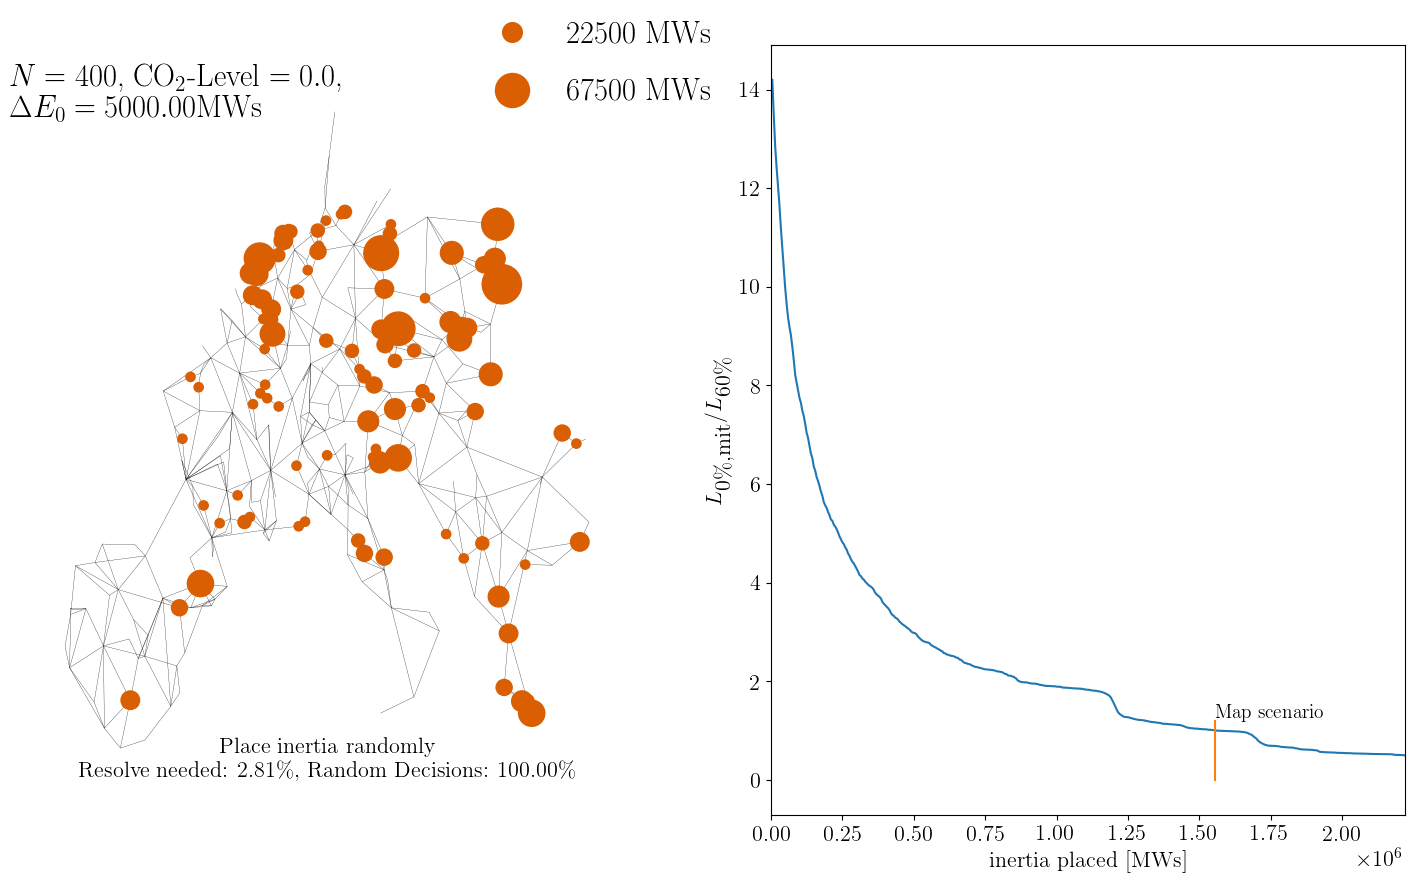

In [8]:
plot_map_inertia_placement_final(co2_lvl = 0.0,
nn=400,
max_iter=10000,
max_node_size=800,
edge_width=0.2,
delta_Erot=5000,
rocof_thres=-1,
l_share=0.0,
resolve_strategy="random",
show_step_number = False,
plot_split_number = False,
save_fig=False,
co2_lvl_ref = 0.6)

## compare mitigation performances

In [3]:
import matplotlib.colors as mcolors
list(mcolors.BASE_COLORS.keys())

['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']

<>:110: SyntaxWarning: invalid escape sequence '\%'
<>:110: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_9404/2727086084.py:110: SyntaxWarning: invalid escape sequence '\%'
  ax_loss.set_ylabel("$L_{\\textrm{loss}}/L_{\\textrm{60\%}}$ (-)")
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


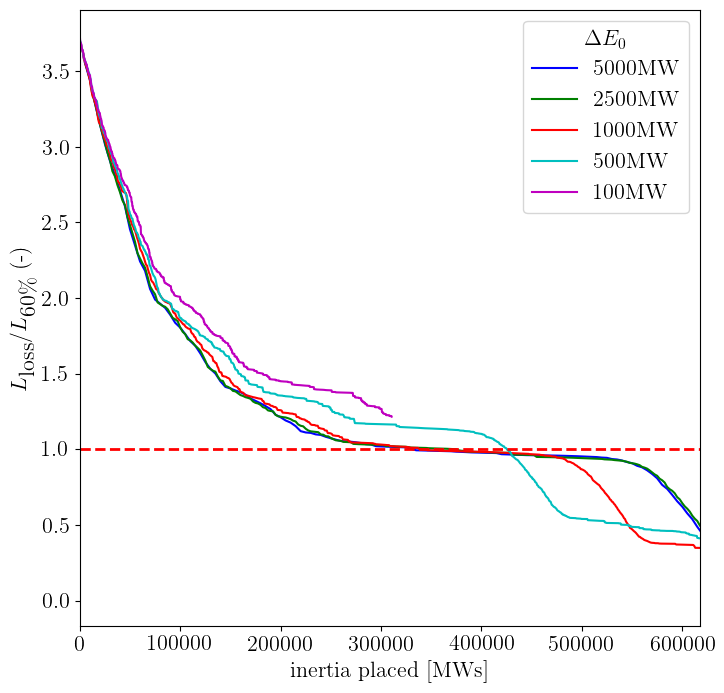

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


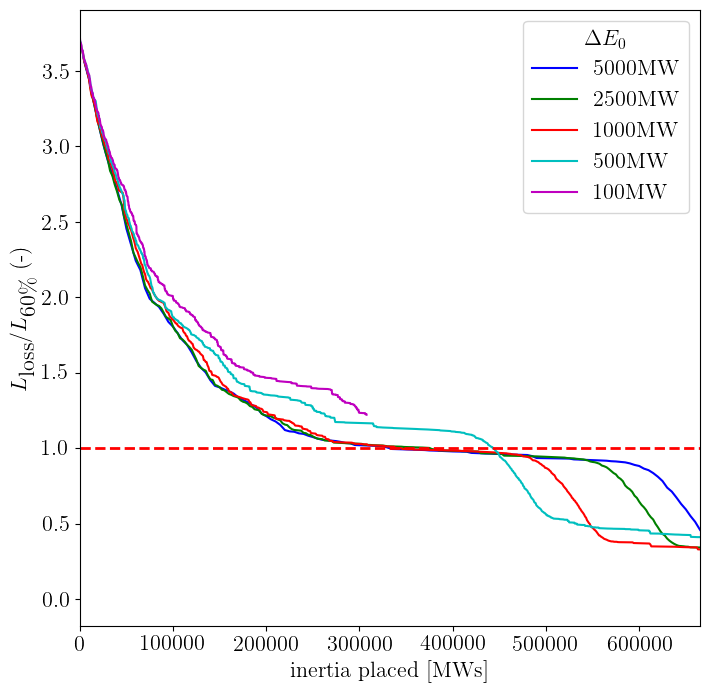

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


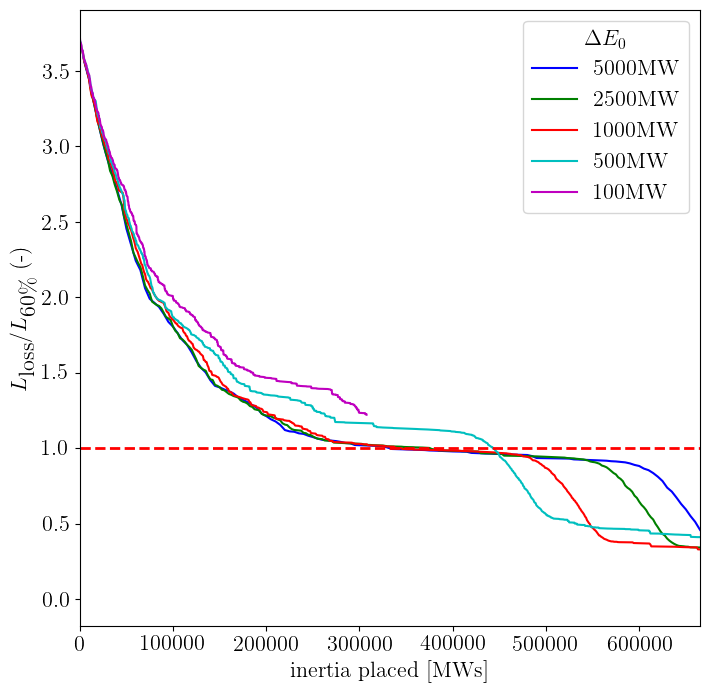

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


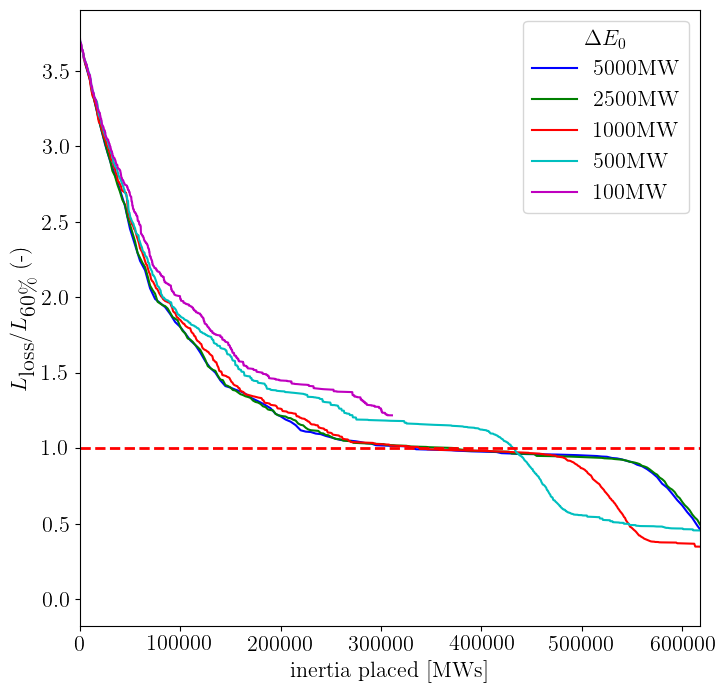

In [24]:
from utils.plot_mitigation_strategies import *
from cycler import cycler


for resolve_strategy in ["concentrate", "hindsight", "hindsight_concentrate", "random"]:
    co2_lvl=0.1
    delta_Erots=[5000, 2500, 1000, 500, 100]
    nn=400
    max_iter=10000
    plot_number_of_splits=False
    show_step_number: bool = False
    save_fig=False
    co2_lvl_ref=0.6

    fig, ax_loss = plt.subplots(1, 1, figsize=(8, 8))
    if plot_number_of_splits:
        ax_number = ax_loss.twinx()
    cc = (cycler(color=['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange']))
    # Load graph
    fpath_pypsa = (
        path_to_pypsa_network_sclopf
        + "sclopf-elec_s_"
        + f"{nn}_ec_lv1.0_Co2L{co2_lvl}-2920SEG.nc"
    )
    pypsa_net = data_handling.load_pypsa_network(fpath_pypsa, use_sclopf=True)
    nx_graph = data_handling.build_networkx_graph(pypsa_net, snet_index=0)
    pos_nodes = networkx.get_node_attributes(nx_graph, "pos")

    # get split properties
    split_properties = pd.read_csv(path_to_evaluation_results+f"split_properties_Co2L{co2_lvl}_n400.csv", index_col=0)
    total_loss_share_rocof_lvl = (split_properties.lost_load_rocof_share*split_properties.snapshot_weighting).sum()
    split_properties = pd.read_csv(path_to_evaluation_results+f"split_properties_Co2L{co2_lvl_ref}_n400.csv", index_col=0)
    total_loss_share_rocof_ref = (split_properties.lost_load_rocof_share*split_properties.snapshot_weighting).sum()

    x_val_half_ref_loss = 0

    for delta_Erot,d in zip(delta_Erots, cc):
        # Load synthetic inertia placement
        fpath_in = (
            path_to_inertia_mitigation_results
            + f"synthetic_inertia_placement_Co2{co2_lvl:.2f}"
            + f"_N{nn}_deltarotE{delta_Erot:.2f}_rocofthres-1.00"
            + f"_lshare0.00_maxiter{max_iter}_{resolve_strategy}.pklz"
        )
        with gzip.open(fpath_in) as fh_in:
            (
                modified_comp_idx,
                _,
                inertia_placed_ls,
                resolve_counter,
                still_random_counter,
            ) = pickle.load(fh_in)

        inertia_placed_res_arr = np.array(inertia_placed_ls)

        inertia_node_idx = inertia_placed_res_arr[:, 1:3]

        node_count_ls = [0] * len(nx_graph)
        for indi_idx_r, indi_count_r in inertia_node_idx:
            node_count_ls[int(indi_idx_r)] += indi_count_r

        ## Plot mitigated lost load and remaining lost splits over time
        total_dangerous_splits = len(modified_comp_idx)
        inertia_placed_arr = np.array(inertia_placed_ls)

        if show_step_number:
            x_vals = inertia_placed_arr[:, 0]
        else:
            cumulative_inertia_placed = np.cumsum(inertia_placed_arr[:, 2] * delta_Erot)
            x_vals = cumulative_inertia_placed

        loss_ref_multiple = (total_loss_share_rocof_lvl-np.cumsum(inertia_placed_arr[:, 3]))/total_loss_share_rocof_ref
        ax_loss.plot(
            x_vals,
            loss_ref_multiple,
            color=d["color"],
            linestyle="-",
            label=f"{delta_Erot}MW",
        )
        # adjust upper xlim
        x_vals_half_ref_loss = x_vals[np.where(loss_ref_multiple<0.5)]
        if len(x_vals_half_ref_loss)>0:
            x_val_half_ref_loss = max(x_val_half_ref_loss, x_vals_half_ref_loss[0])
        
        if plot_number_of_splits:
            ax_number.plot(
                x_vals,
                inertia_placed_arr[:, 4] / total_dangerous_splits,
                color=d["color"],
                linestyle="--",
                label=f"{delta_Erot}MW",
            )
            

    ax_loss.set_xlim(0, x_val_half_ref_loss)
    # xmin, xmax = ax_loss.get_xlim()
    # print((xmin, xmax))
    ax_loss.plot([0, x_val_half_ref_loss], [1, 1], "--", color="red", lw=2)
    # ax_loss.text(2.5*10e6, 1.2, "loss at 60% CO2", ha='right', va='bottom', color="red", fontsize=12)

    ax_loss.legend(title="$\\Delta E_0$")

    if show_step_number:
        ax_loss.set_xlabel("$t_n$")
    else:
        ax_loss.set_xlabel("inertia placed [MWs]")

    if plot_number_of_splits:
        ax_number.set_ylabel("$N_{\\textrm{splits mit}}/N_{\\textrm{splits}}(--)$")
    ax_loss.set_ylabel("$L_{\\textrm{loss}}/L_{\\textrm{60\%}}$ (-)")

    if save_fig:
        fig_path = f"syn_inertia_map_co2lvl{co2_lvl:.2f}_nn{nn}_deltaErot{delta_Erot:.2f}_{resolve_strategy}.png"

        fig.savefig(fig_path, bbox_inches="tight")
        fig.clear()
        plt.close(fig)

    else:
        plt.show()


Results are very similar so we select the simplest:
Random and 5000MW step size

# line extension

In [3]:
from utils.plot_mitigation_strategies import plot_bar_histograms_diff_nnlines, data_line_mitigation_diff_nnlines

/home/mtitz/power-system-split/notebooks/../utils/plot_mitigation_strategies.py:359: SyntaxWarning: invalid escape sequence '\%'
  y_label = y_label.replace("co2string", str(int(100 * co2_lvl)) + "\%")
/home/mtitz/power-system-split/notebooks/../utils/plot_mitigation_strategies.py:360: SyntaxWarning: invalid escape sequence '\%'
  y_label = y_label.replace("co2refString", str(int(100 * co2_lvl_ref)) + "\%")
100%|██████████| 1/1 [00:00<00:00, 45.75it/s]


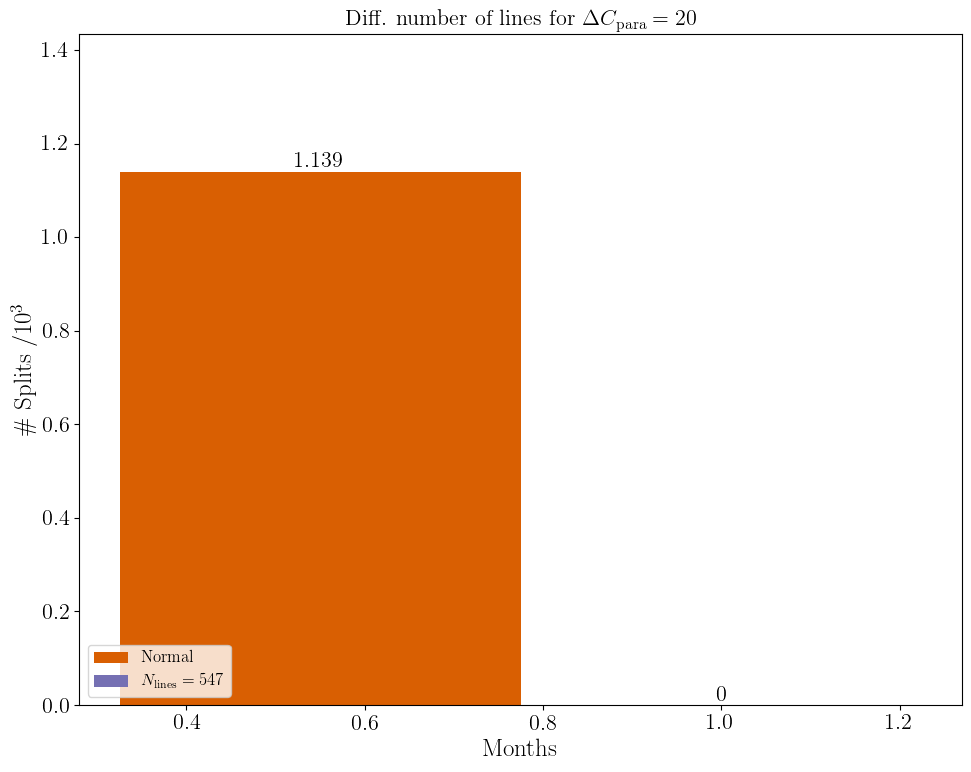

In [15]:
delta_paras=(20,)
n_lines_added=(547,)
# delta_paras=(5,2,1)
# n_lines_added=(20, 10,5)
stop_timestamp_str="2013-01-01 00:00"

for delta_para in delta_paras:
    data_line_mitigation_diff_nnlines(delta_para=delta_para, save_res=True, n_lines_added=n_lines_added, stop_timestamp_str=stop_timestamp_str)
plot_bar_histograms_diff_nnlines(delta_paras, save_fig=False, log_scale=False)

In [6]:
import gzip
import pickle
meta_data_path = path_to_cascade_results
nn_lines = 20
delta_para = 5
stop_timestamp_str="2013-01-01 00:00"
small_change_path = (
            meta_data_path
            + "system_splits_Co2L0.1_n400_"
            + f"lineextension_nnlines{nn_lines}"
            + f"_deltanumpara{delta_para:.4g}_"
            + f"stopped_{stop_timestamp_str}.pklz"
        )
with gzip.open(small_change_path, "rb") as fh_in_r:
     _, vulnerable_edges_r, dict_r = pickle.load(fh_in_r)
     
edge_number_to_nx_edge = {i: (u, v) for i, (u, v) in enumerate(nx_graph.edges())}
nx_edge_to_edge_number = {(u, v):i for i, (u, v) in enumerate(nx_graph.edges())}
# print([nx_edge_to_edge_number[edge] for edge in vulnerable_edges_r])
vulnerable_edge_numbers = [nx_edge_to_edge_number[edge] for edge in vulnerable_edges_r]

print(f"reinforced lines: {vulnerable_edge_numbers}")

print("trigger line pairs should not contain any of the reinforced lines (if num_parrallel is increased by 1 or more)")
trigger_pairs = list(dict_r['2013-01-01 00:00'].keys())
for trigger_pair in trigger_pairs:
    if len(set(trigger_pair).intersection(vulnerable_edge_numbers))>0:
        print(trigger_pair, ": ", dict_r[stop_timestamp_str][trigger_pair])

reinforced lines: [144, 344, 23, 340, 105, 7, 162, 175, 520, 73, 317, 266, 501, 154, 24, 320, 510, 69, 100, 45]
trigger line pairs should not contain any of the reinforced lines (if num_parrallel is increased by 1 or more)
(23, 185) :  [185, 111, 112, 235, 244]
(23, 258) :  [258, 259, 274]
(23, 262) :  [262, 259, 264, 272, 274]
(64, 144) :  [64, 36, 143, 166]
(69, 185) :  [185, 111, 112, 235, 244]
(69, 258) :  [258, 259, 274]
(69, 262) :  [262, 259, 264, 272, 274]
(100, 185) :  [185, 111, 112, 235, 244]
(100, 257) :  [259, 274]
(105, 185) :  [185, 111, 112, 235, 244]
(105, 257) :  [259, 274]
(105, 258) :  [258, 259, 274]
(105, 262) :  [262, 259, 264, 272, 274]
(162, 185) :  [185, 111, 112, 235, 244]
(162, 257) :  [259, 274]
(185, 317) :  [185, 111, 112, 235, 244]
(185, 520) :  [185, 111, 112, 235, 244]
(257, 520) :  [259, 274]
(258, 520) :  [258, 259, 274]
(262, 520) :  [262, 259, 264, 272, 274]


In [33]:
import gzip
import pickle
meta_data_path = path_to_cascade_results
nn_lines = 1
delta_para = 1
stop_timestamp_str="2013-01-01 00:00"
small_change_path = (
            meta_data_path
            + "system_splits_Co2L0.1_n400_"
            + f"lineextension_nnlines{nn_lines}"
            + f"_deltanumpara{delta_para:.4g}_"
            + f"stopped_{stop_timestamp_str}.pklz"
        )
with gzip.open(small_change_path, "rb") as fh_in_r:
     _, vulnerable_edges_r, dict_r = pickle.load(fh_in_r)
     
edge_number_to_nx_edge = {i: (u, v) for i, (u, v) in enumerate(nx_graph.edges())}
nx_edge_to_edge_number = {(u, v):i for i, (u, v) in enumerate(nx_graph.edges())}
# print([nx_edge_to_edge_number[edge] for edge in vulnerable_edges_r])
vulnerable_edge_numbers = [nx_edge_to_edge_number[edge] for edge in vulnerable_edges_r]

print(f"reinforced lines: {vulnerable_edge_numbers}")

print("trigger line pairs should not contain any of the reinforced lines (if num_parrallel is increased by 1 or more)")
trigger_pairs = list(dict_r['2013-01-01 00:00'].keys())
reinforced_but_triggering_idx = []
unexperced_triggering_pairs_idx = []
for trigger_pair in trigger_pairs:
    if len(set(trigger_pair).intersection(vulnerable_edge_numbers))>0:
        print(trigger_pair)
        if trigger_pair[0] in vulnerable_edge_numbers:
            reinforced_but_triggering_idx.append(trigger_pair[0])
        if trigger_pair[1] in vulnerable_edge_numbers:
            reinforced_but_triggering_idx.append(trigger_pair[1])
        unexperced_triggering_pairs_idx.append(trigger_pair)
reinforced_but_triggering_idx = list(set(reinforced_but_triggering_idx))
reinforced_but_triggering_edges = [edge_number_to_nx_edge[edge] for edge in reinforced_but_triggering_idx]
unexperced_triggering_pairs_edges = [(edge_number_to_nx_edge[trigger_pair[0]], edge_number_to_nx_edge[trigger_pair[1]]) for trigger_pair in unexperced_triggering_pairs_idx]

reinforced lines: [144]
trigger line pairs should not contain any of the reinforced lines (if num_parrallel is increased by 1 or more)
(64, 144)
(105, 144)
(144, 520)
(144, 144)


In [7]:
from matplotlib import pyplot as plt
from utils.plot_mitigation_strategies import plot_map_marked_edges

plot_map_marked_edges(nx_graph, pos, vulnerable_edges_r, unexperced_triggering_pairs_edges[0])

NameError: name 'unexperced_triggering_pairs_edges' is not defined

In [ ]:

edges = nx.draw_networkx_edges(nx_graph,
                        pos=pos,
                        ax=ax,
                        # edgelist=[number_to_edge_dict[line] for line in pair],
                        edge_color="grey",
                        # style=style,
                        width=1.5,
                        # edge_cmap=cmap,
                        # edge_vmin=np.log10(vmin),
                        # edge_vmax=np.log10(vmax)
                        )
edges = nx.draw_networkx_edges(nx_graph,
                        pos=pos,
                        ax=ax,
                        edgelist=vulnerable_edges_r,
                        edge_color="red",
                        # style=style,
                        width=10,
                        # edge_cmap=cmap,
                        # edge_vmin=np.log10(vmin),
                        # edge_vmax=np.log10(vmax)
                        )
edges = nx.draw_networkx_edges(nx_graph,
                        pos=pos,
                        ax=ax,
                        edgelist=vulnerable_edges_r,
                        edge_color="red",
                        # style=style,
                        width=10,
                        # edge_cmap=cmap,
                        # edge_vmin=np.log10(vmin),
                        # edge_vmax=np.log10(vmax)
                        )

In [34]:
from utils.cascade_simulation import LOOKUP_TABLE_NP
(LOOKUP_TABLE_NP[:,0] - LOOKUP_TABLE_NP[:,1])

array([0.28947368, 0.28947369, 0.59210526, 0.28947368, 0.59210527,
       1.        , 0.28947369, 0.59210527, 1.        , 0.28947368,
       0.59210526, 1.        , 1.        , 0.28947369, 0.59210526,
       1.        , 1.        , 0.28947368, 0.59210526, 1.        ,
       1.        , 1.        , 0.28947368, 0.59210526, 1.        ,
       1.        , 1.        , 0.59210527, 1.        , 1.        ,
       1.        ])

100%|██████████| 1/1 [00:00<00:00, 48.66it/s]


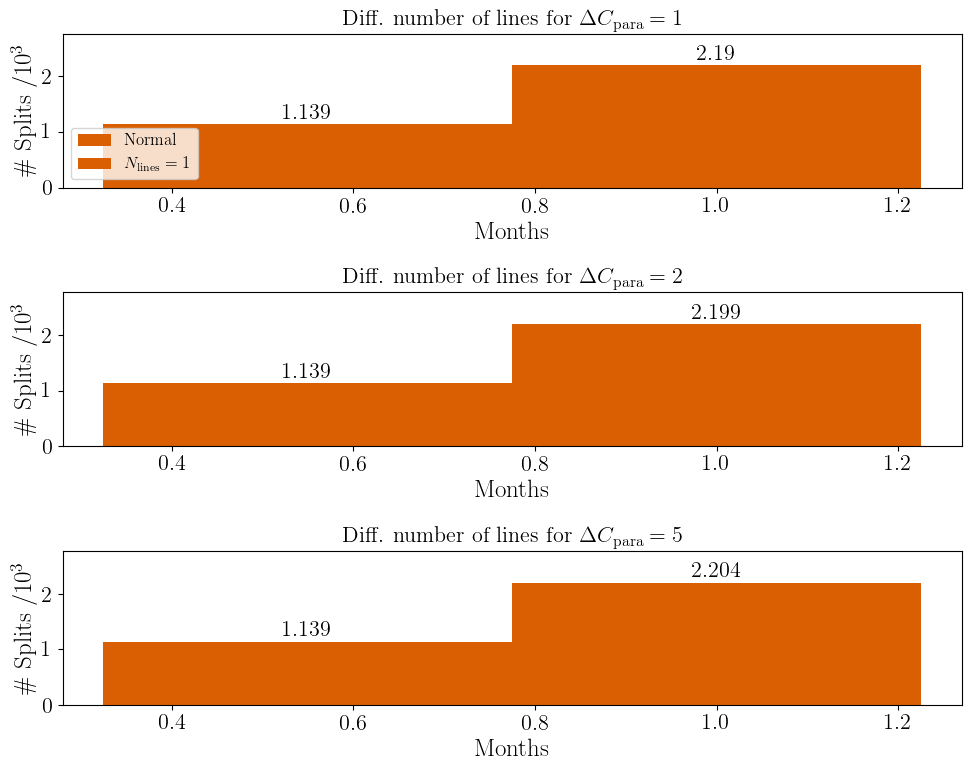

In [5]:
stop_timestamp_str = "2013-01-01 00:00"
delta_paras=[1, 2, 5]
# n_lines_added=[547, 20, 10, 5]
n_lines_added=[1]
norm_month_diff_para_tuples = []
for delta_para in delta_paras:
    norm_splits_per_month, mitigate_split_ls = data_line_mitigation_diff_nnlines(delta_para=delta_para, save_res=True, n_lines_added=n_lines_added, stop_timestamp_str=stop_timestamp_str)
    # norm_month_diff_para_tuples.append((norm_splits_per_month, mitigate_split_ls, delta_para))
plot_bar_histograms_diff_nnlines(delta_paras, save_fig=False, log_scale=False, 
                                #  norm_month_diff_para_tuples=norm_month_diff_para_tuples
                                 )

In [12]:
import gzip
import pickle
meta_data_path = path_to_cascade_results
nn_lines = 1
delta_para = 2
small_change_path = (
            meta_data_path
            + "system_splits_Co2L0.1_n400_"
            + f"lineextension_nnlines{nn_lines}"
            + f"_deltanumpara{delta_para:.4g}_"
            + f"stopped_{stop_timestamp_str}.pklz"
        )
with gzip.open(small_change_path, "rb") as fh_in_r:
     importance_all_lines, vulnerable_edges_r, dict_r = pickle.load(fh_in_r)
     
edge_number_to_nx_edge = {i: (u, v) for i, (u, v) in enumerate(nx_graph.edges())}
nx_edge_to_edge_number = {(u, v):i for i, (u, v) in enumerate(nx_graph.edges())}
# print([nx_edge_to_edge_number[edge] for edge in vulnerable_edges_r])
vulnerable_edge_numbers = [nx_edge_to_edge_number[edge] for edge in vulnerable_edges_r]

print(f"reinforced lines: {vulnerable_edge_numbers}")

print("trigger line pairs should not contain any of the reinforced lines (if num_parrallel is increased by 1 or more)")
trigger_pairs = list(dict_r['2013-01-01 00:00'].keys())
for trigger_pair in trigger_pairs:
    if len(set(trigger_pair).intersection(vulnerable_edge_numbers))>0:
        print(trigger_pair)

reinforced lines: [144]
trigger line pairs should not contain any of the reinforced lines (if num_parrallel is increased by 1 or more)
(144, 185)
(144, 257)
(144, 258)
(144, 262)


In [9]:
trigger_pairs

[(0, 185),
 (0, 257),
 (0, 258),
 (0, 262),
 (1, 185),
 (1, 257),
 (1, 258),
 (1, 262),
 (2, 185),
 (2, 257),
 (2, 258),
 (2, 262),
 (3, 185),
 (3, 257),
 (3, 258),
 (3, 262),
 (4, 185),
 (4, 257),
 (4, 258),
 (4, 262),
 (5, 185),
 (5, 257),
 (5, 258),
 (5, 262),
 (6, 185),
 (6, 257),
 (6, 258),
 (6, 262),
 (7, 185),
 (7, 257),
 (7, 258),
 (7, 262),
 (8, 185),
 (8, 257),
 (8, 258),
 (8, 262),
 (9, 185),
 (9, 257),
 (9, 258),
 (9, 262),
 (10, 185),
 (10, 257),
 (10, 258),
 (10, 262),
 (11, 185),
 (11, 257),
 (11, 258),
 (11, 262),
 (12, 185),
 (12, 257),
 (12, 258),
 (12, 262),
 (13, 185),
 (13, 257),
 (13, 258),
 (13, 262),
 (14, 185),
 (14, 257),
 (14, 258),
 (14, 262),
 (15, 185),
 (15, 257),
 (15, 258),
 (15, 262),
 (16, 185),
 (16, 257),
 (16, 258),
 (16, 262),
 (17, 185),
 (17, 257),
 (17, 258),
 (17, 262),
 (18, 185),
 (18, 257),
 (18, 258),
 (18, 262),
 (19, 185),
 (19, 257),
 (19, 258),
 (19, 262),
 (20, 105),
 (20, 185),
 (20, 257),
 (20, 258),
 (20, 262),
 (20, 520),
 (21, 18

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

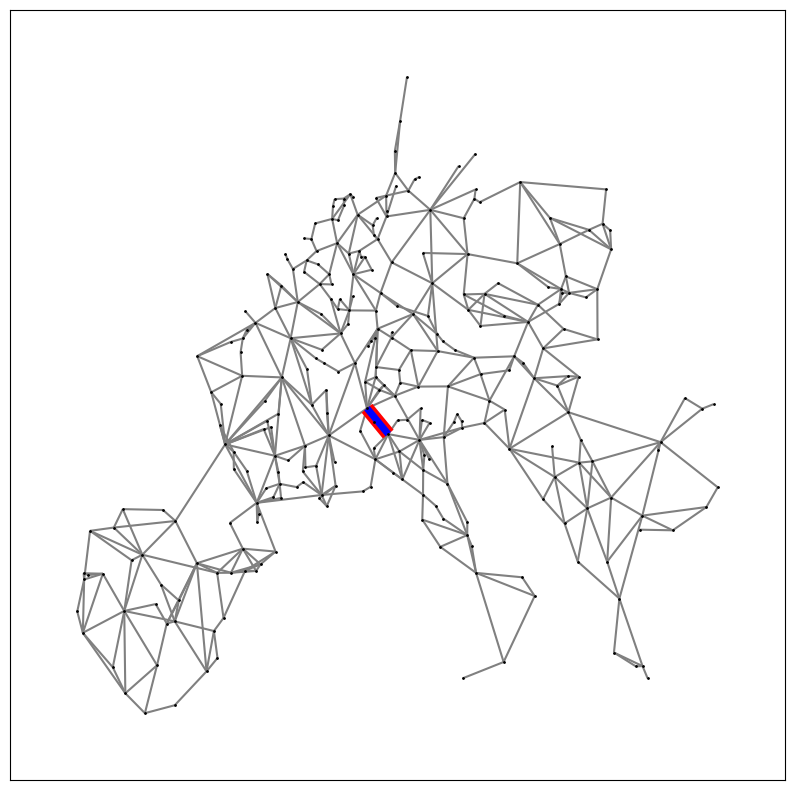

In [8]:
from matplotlib import pyplot as plt
from utils.plot_mitigation_strategies import plot_map_marked_edges

plot_map_marked_edges(nx_graph, pos, vulnerable_edges_r, vulnerable_edges_r)